**Optimization in Linear Regression: Gradient Descent**

While Ordinary Least Squares (OLS) provides an exact analytical solution, it is not always feasible for large-scale datasets due to its $O(n^3)$ computational complexity. This is where Gradient Descent comes in.

**What is Gradient Descent?**

Gradient Descent is an iterative first-order optimization algorithm used to find the local minimum of a function. In Linear Regression, we use it to minimize the Cost Function (MSE) by gradually adjusting the model's parameters (weights and bias).

We calculate the partial derivatives of the MSE with respect to each parameter:

Weight Gradient ($\frac{\partial L}{\partial w}$): $\frac{-2}{n} \sum X(y - \hat{y})$

Bias Gradient ($\frac{\partial L}{\partial b}$): $\frac{-2}{n} \sum (y - \hat{y})$

We then update the parameters:

$$w_{new} = w_{old} - (\eta \cdot \frac{\partial L}{\partial w})$$

$$b_{new} = b_{old} - (\eta \cdot \frac{\partial L}{\partial b})$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [2]:
diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target.reshape(-1, 1)

Standardise the features - if features have different scales, GD will take forever to converge

In [3]:
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

In [13]:
n_samples, n_features = X_std.shape
weights = np.zeros((n_features, 1))
bias = 0

learning_rate = 0.001
epochs = 5000

In [14]:
loss_history = []

for i in range(epochs):
    y_pred = np.dot(X_std, weights) + bias
    
    loss = np.mean((y - y_pred)**2)
    loss_history.append(loss)
    
    dw = (-2 / n_samples) * np.dot(X_std.T, (y - y_pred))
    db = (-2 / n_samples) * np.sum(y - y_pred)
    
    weights -= learning_rate * dw
    bias -= learning_rate * db
    
    print(f"Epoch {i}: Loss {loss:.4f}")

print("\nTraining Complete.")

Epoch 0: Loss 29074.4819
Epoch 1: Loss 28947.5159
Epoch 2: Loss 28821.4126
Epoch 3: Loss 28696.1627
Epoch 4: Loss 28571.7575
Epoch 5: Loss 28448.1879
Epoch 6: Loss 28325.4452
Epoch 7: Loss 28203.5208
Epoch 8: Loss 28082.4063
Epoch 9: Loss 27962.0931
Epoch 10: Loss 27842.5731
Epoch 11: Loss 27723.8381
Epoch 12: Loss 27605.8800
Epoch 13: Loss 27488.6909
Epoch 14: Loss 27372.2631
Epoch 15: Loss 27256.5887
Epoch 16: Loss 27141.6601
Epoch 17: Loss 27027.4699
Epoch 18: Loss 26914.0106
Epoch 19: Loss 26801.2750
Epoch 20: Loss 26689.2559
Epoch 21: Loss 26577.9460
Epoch 22: Loss 26467.3385
Epoch 23: Loss 26357.4264
Epoch 24: Loss 26248.2028
Epoch 25: Loss 26139.6612
Epoch 26: Loss 26031.7947
Epoch 27: Loss 25924.5969
Epoch 28: Loss 25818.0613
Epoch 29: Loss 25712.1815
Epoch 30: Loss 25606.9513
Epoch 31: Loss 25502.3643
Epoch 32: Loss 25398.4146
Epoch 33: Loss 25295.0960
Epoch 34: Loss 25192.4027
Epoch 35: Loss 25090.3286
Epoch 36: Loss 24988.8680
Epoch 37: Loss 24888.0152
Epoch 38: Loss 24787.7

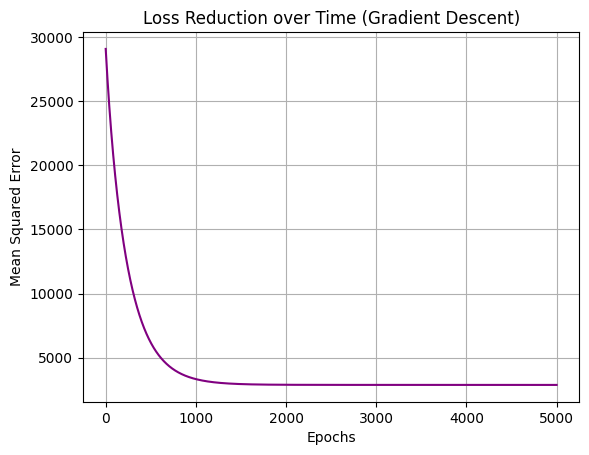

In [15]:
plt.plot(range(epochs), loss_history, color='purple')
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Loss Reduction over Time (Gradient Descent)")
plt.grid(True)
plt.show()

Gradient Descent is best for large datasets, the time taken is O(kn) which is very less compared to what OLS was taking which is O(n^3). 